# Analyzer

The strategy is simple.

We want to be invested proportionally to the confidence score and in the direction of the signal.

In [2]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('exports/contrarian_signals_20260112_115224.csv')

# Filter for BTC, ETH, and SOL only
df_filtered = df[df['coin'].isin(['BTC', 'ETH', 'SOL'])].copy()

# Sort by coin and timestamp
df_filtered = df_filtered.sort_values(['coin', 'timestamp']).reset_index(drop=True)

print(f"Total signals: {len(df_filtered)}")
print(f"\nSignals per coin:")
print(df_filtered['coin'].value_counts())

Total signals: 3753

Signals per coin:
coin
BTC    1251
ETH    1251
SOL    1251
Name: count, dtype: int64


In [3]:
# Calculate price change (return) for each period
# Group by coin and calculate the NEXT price (not previous)
df_filtered['next_price'] = df_filtered.groupby('coin')['current_price'].shift(-1)

# Calculate return: (next_price - current_price) / current_price
df_filtered['price_return'] = (df_filtered['next_price'] - df_filtered['current_price']) / df_filtered['current_price']

# Drop rows with NaN returns (last row of each coin)
df_filtered = df_filtered.dropna(subset=['price_return']).reset_index(drop=True)

print(f"Signals after removing NaN returns: {len(df_filtered)}")
print(f"\nSignals per coin:")
print(df_filtered['coin'].value_counts())

# Display sample
print("\nSample with returns:")
display(df_filtered[['coin', 'timestamp', 'current_price', 'next_price', 'price_return']].head(10))

Signals after removing NaN returns: 2844

Signals per coin:
coin
BTC    948
ETH    948
SOL    948
Name: count, dtype: int64

Sample with returns:


,coin,timestamp,current_price,next_price,price_return
0,BTC,2025-12-23 09:08:59,87545.5,87294.5,-0.002867
1,BTC,2025-12-23 09:39:34,87294.5,87506.5,0.002429
2,BTC,2025-12-23 10:10:08,87506.5,87575.5,0.000789
3,BTC,2025-12-23 10:40:42,87575.5,87661.5,0.000982
4,BTC,2025-12-23 11:11:17,87661.5,87746.5,0.000970
5,BTC,2025-12-23 11:41:51,87746.5,87840.5,0.001071
6,BTC,2025-12-23 12:12:25,87840.5,87844.5,0.000046
7,BTC,2025-12-23 12:43:00,87844.5,87741.5,-0.001173
8,BTC,2025-12-23 13:13:34,87741.5,87653.5,-0.001003
9,BTC,2025-12-23 13:44:09,87653.5,87748.5,0.001084


In [4]:
# Calculate position size based on confidence score
# Max capacity = $100,000 divide for the 3 assets
df_filtered['position_size'] = df_filtered['confidence_score'] * 100000 / 3

# For SHORT signals, position is negative (we profit when price goes down)
# For LONG signals, position is positive (we profit when price goes up)
df_filtered['position_direction'] = df_filtered['signal_direction'].map({'LONG': 1, 'SHORT': -1})

# Calculate P&L for the period
# P&L = position_size * position_direction * price_return
df_filtered['period_pnl'] = df_filtered['position_size'] * df_filtered['position_direction'] * df_filtered['price_return']

# Display results
print("Strategy Results:")
display(df_filtered[['coin', 'timestamp', 'signal_direction', 'confidence_score', 
                      'position_size', 'price_return', 'period_pnl']].head(15))

Strategy Results:


,coin,timestamp,signal_direction,confidence_score,position_size,price_return,period_pnl
0,BTC,2025-12-23 09:08:59,SHORT,0.282,9400.000000,-0.002867,26.950557
1,BTC,2025-12-23 09:39:34,SHORT,0.254,8466.666667,0.002429,-20.561815
2,BTC,2025-12-23 10:10:08,SHORT,0.273,9100.000000,0.000789,-7.175467
3,BTC,2025-12-23 10:40:42,SHORT,0.285,9500.000000,0.000982,-9.329093
4,BTC,2025-12-23 11:11:17,SHORT,0.317,10566.666667,0.000970,-10.245851
5,BTC,2025-12-23 11:41:51,SHORT,0.314,10466.666667,0.001071,-11.212603
6,BTC,2025-12-23 12:12:25,SHORT,0.320,10666.666667,0.000046,-0.485729
7,BTC,2025-12-23 12:43:00,SHORT,0.321,10700.000000,-0.001173,12.546033
8,BTC,2025-12-23 13:13:34,SHORT,0.307,10233.333333,-0.001003,10.263482
9,BTC,2025-12-23 13:44:09,SHORT,0.290,9666.666667,0.001084,-10.476859


In [5]:
# Remove first period for each coin (no previous price to calculate return)
df_results = df_filtered.dropna(subset=['period_pnl'])

# Overall statistics
print("="*80)
print("OVERALL PERFORMANCE")
print("="*80)
print(f"Total P&L: ${df_results['period_pnl'].sum():.2f}")
print(f"Average P&L per trade: ${df_results['period_pnl'].mean():.2f}")
print(f"Win rate: {(df_results['period_pnl'] > 0).sum() / len(df_results) * 100:.2f}%")
print(f"Total trades: {len(df_results)}")

# Performance by coin
print("\n" + "="*80)
print("PERFORMANCE BY COIN")
print("="*80)
by_coin = df_results.groupby('coin').agg({
    'period_pnl': ['sum', 'mean', 'count'],
}).round(2)
display(by_coin)

# Performance by signal direction
print("\n" + "="*80)
print("PERFORMANCE BY SIGNAL DIRECTION")
print("="*80)
by_signal = df_results.groupby('signal_direction').agg({
    'period_pnl': ['sum', 'mean', 'count'],
}).round(2)
display(by_signal)

OVERALL PERFORMANCE
Total P&L: $-2403.73
Average P&L per trade: $-0.85
Win rate: 47.78%
Total trades: 2844

PERFORMANCE BY COIN


period_pnl            
            sum  mean count
coin                       
BTC     -537.88 -0.57   948
ETH     -917.70 -0.97   948
SOL     -948.15 -1.00   948


PERFORMANCE BY SIGNAL DIRECTION


period_pnl            
                        sum  mean count
signal_direction                       
SHORT              -2403.73 -0.85  2844

In [6]:
# Total volume traded per coin
print("="*80)
print("TOTAL VOLUME TRADED BY COIN")
print("="*80)

# Calculate position value at end of each period (position_size + period_pnl)
df_results['position_value_end'] = df_results['position_size'] + df_results['period_pnl'] * df_results['position_direction']
# Get previous position value (which is the position_size for current period)
df_results['prev_position_value'] = df_results.groupby('coin')['position_value_end'].shift(1).fillna(0)

# Volume traded = absolute change in position
df_results['volume_traded'] = abs(df_results['position_size'] - df_results['prev_position_value'])

volume_by_coin = df_results.groupby('coin').agg({
    'volume_traded': 'sum'
}).round(2)
volume_by_coin.columns = ['Total_Volume_Traded']

print("\nVolume Traded (sum of position changes):")
display(volume_by_coin)

print(f"\nTotal volume traded across all coins: ${df_results['volume_traded'].sum():.2f}")

# assuming first fee tier in Bybit
print(f"\nFees if all maker: ${df_results['volume_traded'].sum()*0.0002:.2f}")
print(f"\nFees if all taker: ${df_results['volume_traded'].sum()*0.00055:.2f}")

TOTAL VOLUME TRADED BY COIN

Volume Traded (sum of position changes):


,Total_Volume_Traded
coin,
BTC,390890.72
ETH,368137.28
SOL,461218.76



Total volume traded across all coins: $1220246.76

Fees if all maker: $244.05

Fees if all taker: $671.14


In [7]:
# Calculate cumulative P&L by coin
df_results['cumulative_pnl'] = df_results.groupby('coin')['period_pnl'].cumsum()

# Display final cumulative P&L
print("Final Cumulative P&L by Coin:")
final_pnl = df_results.groupby('coin')['cumulative_pnl'].last()
display(final_pnl)

# Show evolution over time
print("\nCumulative P&L over time (last 10 periods per coin):")
display(df_results[['coin', 'timestamp', 'period_pnl', 'cumulative_pnl']].tail(10))

Final Cumulative P&L by Coin:


coin
BTC   -537.876397
ETH   -917.698834
SOL   -948.153261
Name: cumulative_pnl, dtype: float64


Cumulative P&L over time (last 10 periods per coin):


,coin,timestamp,period_pnl,cumulative_pnl
2834,SOL,2026-01-12 05:35:13,27.281097,-1226.406513
2835,SOL,2026-01-12 06:05:49,53.998949,-1172.407564
2836,SOL,2026-01-12 06:36:24,-22.989315,-1195.396878
2837,SOL,2026-01-12 07:07:00,68.518974,-1126.877904
2838,SOL,2026-01-12 07:37:36,11.227600,-1115.650305
2839,SOL,2026-01-12 08:08:11,104.599041,-1011.051264
2840,SOL,2026-01-12 08:38:47,52.153048,-958.898216
2841,SOL,2026-01-12 09:09:23,4.226746,-954.671470
2842,SOL,2026-01-12 09:39:59,-35.274328,-989.945798
2843,SOL,2026-01-12 10:10:35,41.792537,-948.153261


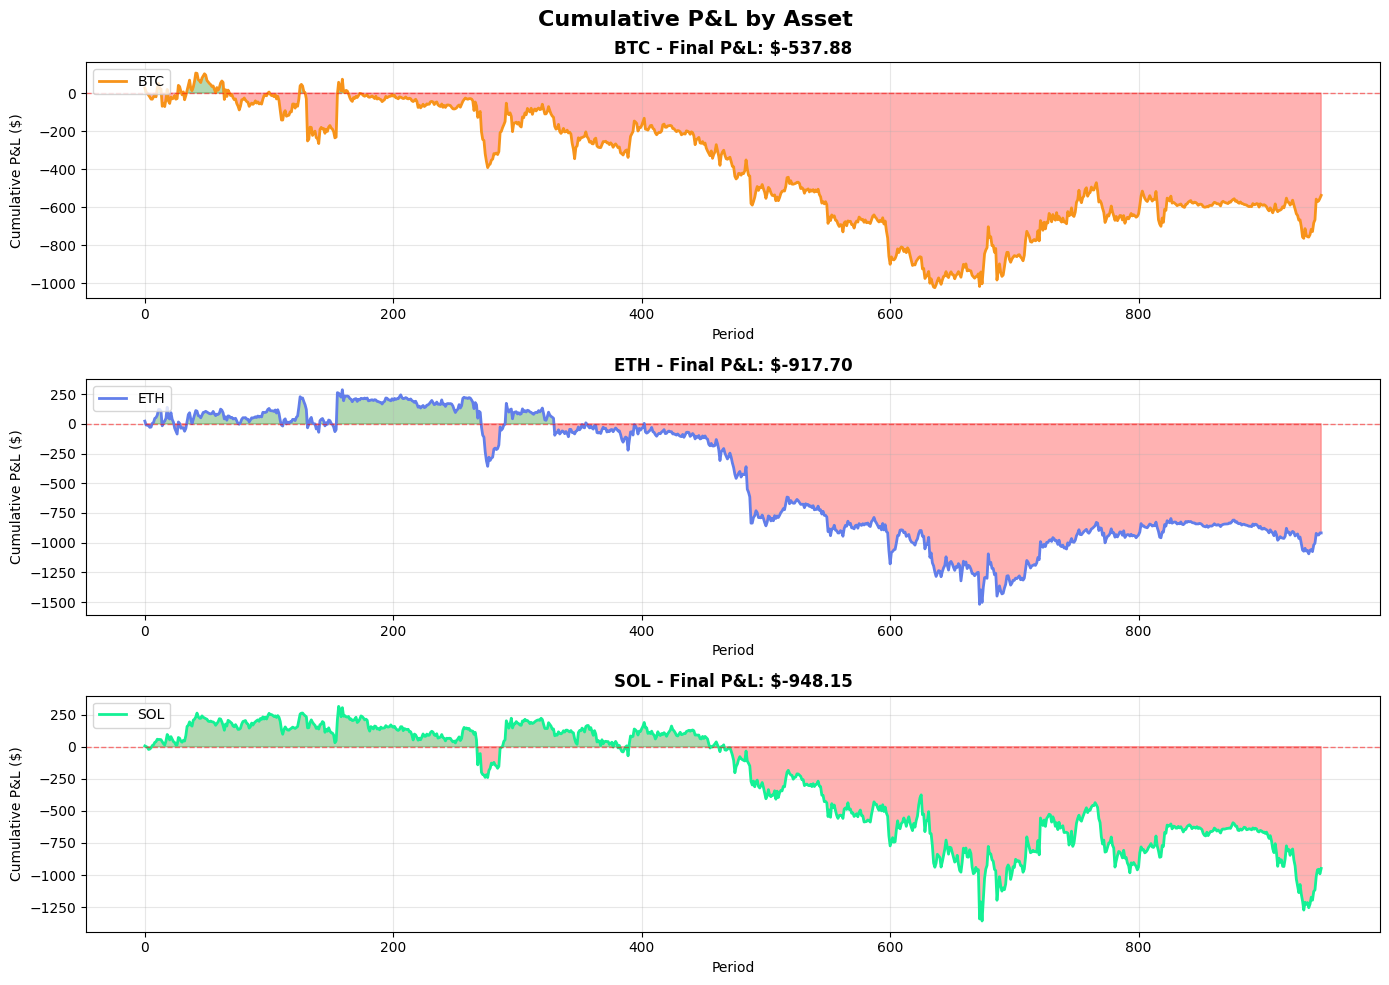

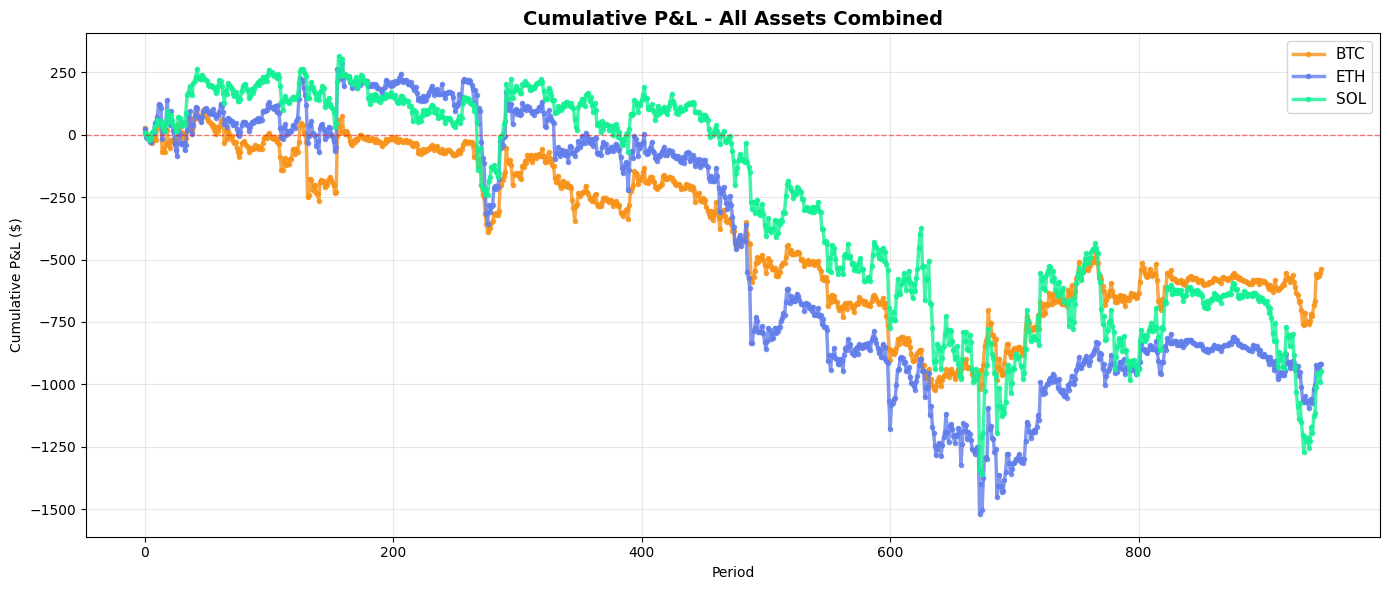

In [8]:
import matplotlib.pyplot as plt

# Create figure with subplots for each coin
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Cumulative P&L by Asset', fontsize=16, fontweight='bold')

coins = ['BTC', 'ETH', 'SOL']
colors = ['#F7931A', '#627EEA', '#14F195']  # BTC orange, ETH purple, SOL green

for idx, (coin, color) in enumerate(zip(coins, colors)):
    coin_data = df_results[df_results['coin'] == coin].copy()
    
    ax = axes[idx]
    ax.plot(range(len(coin_data)), coin_data['cumulative_pnl'], 
            color=color, linewidth=2, label=coin)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.fill_between(range(len(coin_data)), coin_data['cumulative_pnl'], 0, 
                     where=(coin_data['cumulative_pnl'] >= 0), alpha=0.3, color='green')
    ax.fill_between(range(len(coin_data)), coin_data['cumulative_pnl'], 0, 
                     where=(coin_data['cumulative_pnl'] < 0), alpha=0.3, color='red')
    
    ax.set_title(f'{coin} - Final P&L: ${coin_data["cumulative_pnl"].iloc[-1]:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Period')
    ax.set_ylabel('Cumulative P&L ($)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Combined chart
plt.figure(figsize=(14, 6))
for coin, color in zip(coins, colors):
    coin_data = df_results[df_results['coin'] == coin].copy()
    plt.plot(range(len(coin_data)), coin_data['cumulative_pnl'], 
             color=color, linewidth=2.5, label=coin, marker='o', markersize=3, alpha=0.8)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Cumulative P&L - All Assets Combined', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Cumulative P&L ($)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Aggregate P&L across all coins for each timestamp (portfolio level)
portfolio_pnl = df_results.groupby('timestamp').agg({
    'period_pnl': 'sum'
}).reset_index()

# Sort by timestamp
portfolio_pnl = portfolio_pnl.sort_values('timestamp').reset_index(drop=True)

# Calculate cumulative P&L for portfolio
portfolio_pnl['cumulative_pnl'] = portfolio_pnl['period_pnl'].cumsum()

print("="*80)
print("PORTFOLIO PERFORMANCE")
print("="*80)
print(f"\nTotal Portfolio P&L: ${portfolio_pnl['cumulative_pnl'].iloc[-1]:.2f}")
print(f"Average Period P&L: ${portfolio_pnl['period_pnl'].mean():.2f}")
print(f"Best Period: ${portfolio_pnl['period_pnl'].max():.2f}")
print(f"Worst Period: ${portfolio_pnl['period_pnl'].min():.2f}")
print(f"Winning Periods: {(portfolio_pnl['period_pnl'] > 0).sum()} ({(portfolio_pnl['period_pnl'] > 0).sum() / len(portfolio_pnl) * 100:.2f}%)")

print("\n" + "="*80)
print("PORTFOLIO EVOLUTION (Last 10 Periods)")
print("="*80)
display(portfolio_pnl[['timestamp', 'period_pnl', 'cumulative_pnl']].tail(10))

PORTFOLIO PERFORMANCE

Total Portfolio P&L: $-2403.73
Average Period P&L: $-2.50
Best Period: $698.86
Worst Period: $-719.59
Winning Periods: 471 (48.91%)

PORTFOLIO EVOLUTION (Last 10 Periods)


,timestamp,period_pnl,cumulative_pnl
953,2026-01-12 05:35:13,69.901933,-3034.655379
954,2026-01-12 06:05:49,88.696486,-2945.958893
955,2026-01-12 06:36:24,-52.699230,-2998.658123
956,2026-01-12 07:07:00,171.124775,-2827.533348
957,2026-01-12 07:37:36,41.149473,-2786.383875
958,2026-01-12 08:08:11,296.442395,-2489.941480
959,2026-01-12 08:38:47,25.472247,-2464.469233
960,2026-01-12 09:09:23,8.379066,-2456.090166
961,2026-01-12 09:39:59,-4.203724,-2460.293890
962,2026-01-12 10:10:35,56.565398,-2403.728492


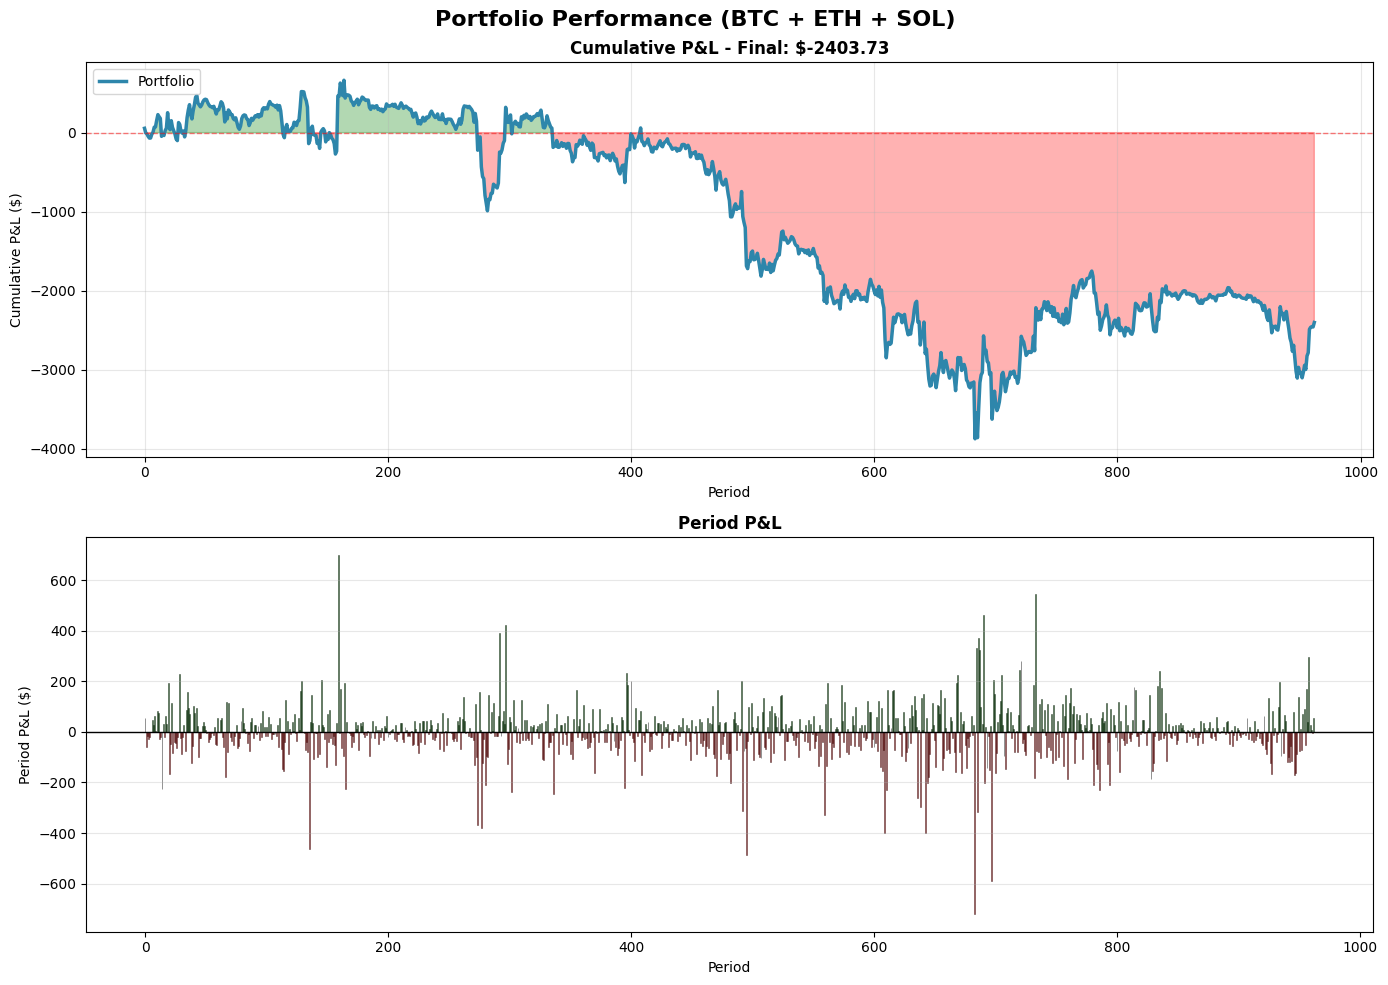

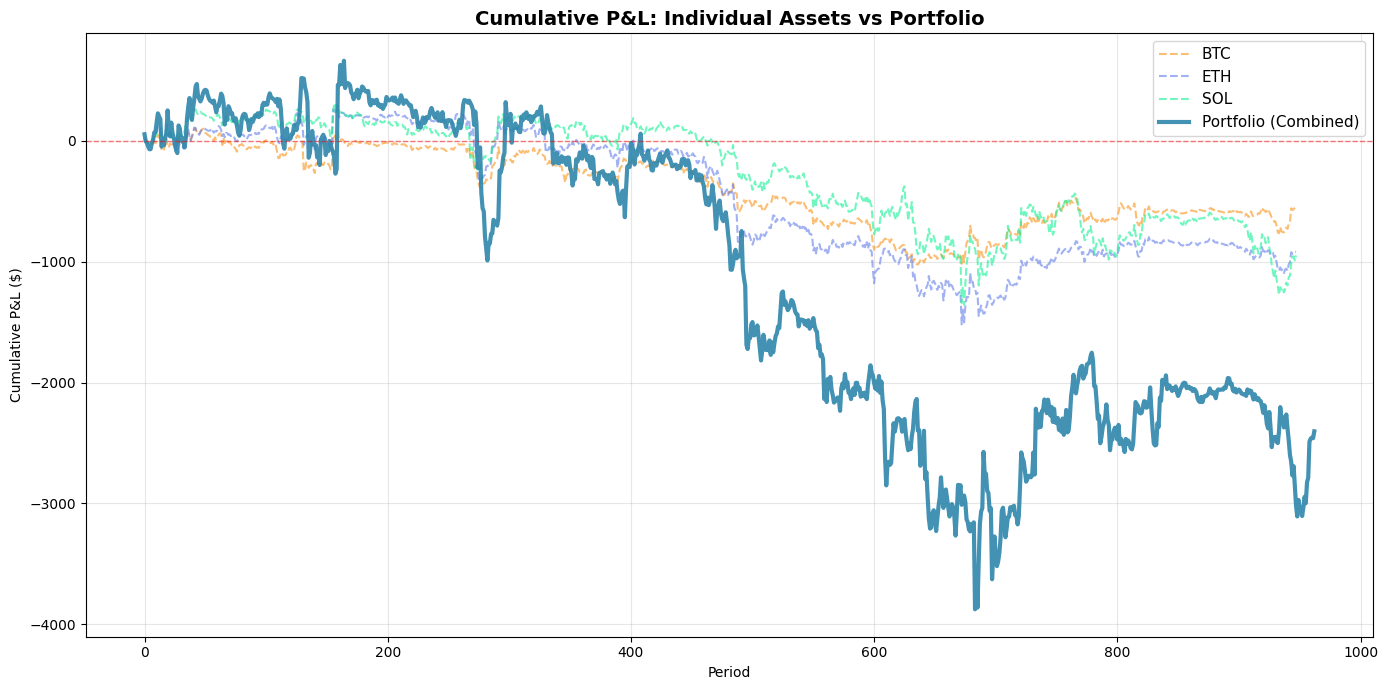

In [10]:
import matplotlib.pyplot as plt

# Portfolio chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Portfolio Performance (BTC + ETH + SOL)', fontsize=16, fontweight='bold')

# Cumulative P&L
ax1.plot(range(len(portfolio_pnl)), portfolio_pnl['cumulative_pnl'], 
         color='#2E86AB', linewidth=2.5, label='Portfolio')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax1.fill_between(range(len(portfolio_pnl)), portfolio_pnl['cumulative_pnl'], 0, 
                 where=(portfolio_pnl['cumulative_pnl'] >= 0), alpha=0.3, color='green')
ax1.fill_between(range(len(portfolio_pnl)), portfolio_pnl['cumulative_pnl'], 0, 
                 where=(portfolio_pnl['cumulative_pnl'] < 0), alpha=0.3, color='red')

ax1.set_title(f'Cumulative P&L - Final: ${portfolio_pnl["cumulative_pnl"].iloc[-1]:.2f}', 
             fontsize=12, fontweight='bold')
ax1.set_xlabel('Period')
ax1.set_ylabel('Cumulative P&L ($)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Period P&L (bar chart)
colors = ['green' if x > 0 else 'red' for x in portfolio_pnl['period_pnl']]
ax2.bar(range(len(portfolio_pnl)), portfolio_pnl['period_pnl'], 
        color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)

ax2.set_title('Period P&L', fontsize=12, fontweight='bold')
ax2.set_xlabel('Period')
ax2.set_ylabel('Period P&L ($)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Combined view: Individual coins + Portfolio
plt.figure(figsize=(14, 7))

coins = ['BTC', 'ETH', 'SOL']
colors = ['#F7931A', '#627EEA', '#14F195']

# Plot individual coins (from df_results)
for coin, color in zip(coins, colors):
    coin_data = df_results[df_results['coin'] == coin].copy()
    plt.plot(range(len(coin_data)), coin_data['cumulative_pnl'], 
             color=color, linewidth=1.5, label=coin, alpha=0.6, linestyle='--')

# Plot portfolio
plt.plot(range(len(portfolio_pnl)), portfolio_pnl['cumulative_pnl'], 
         color='#2E86AB', linewidth=3, label='Portfolio (Combined)', alpha=0.9)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Cumulative P&L: Individual Assets vs Portfolio', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Cumulative P&L ($)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Statistical Tests

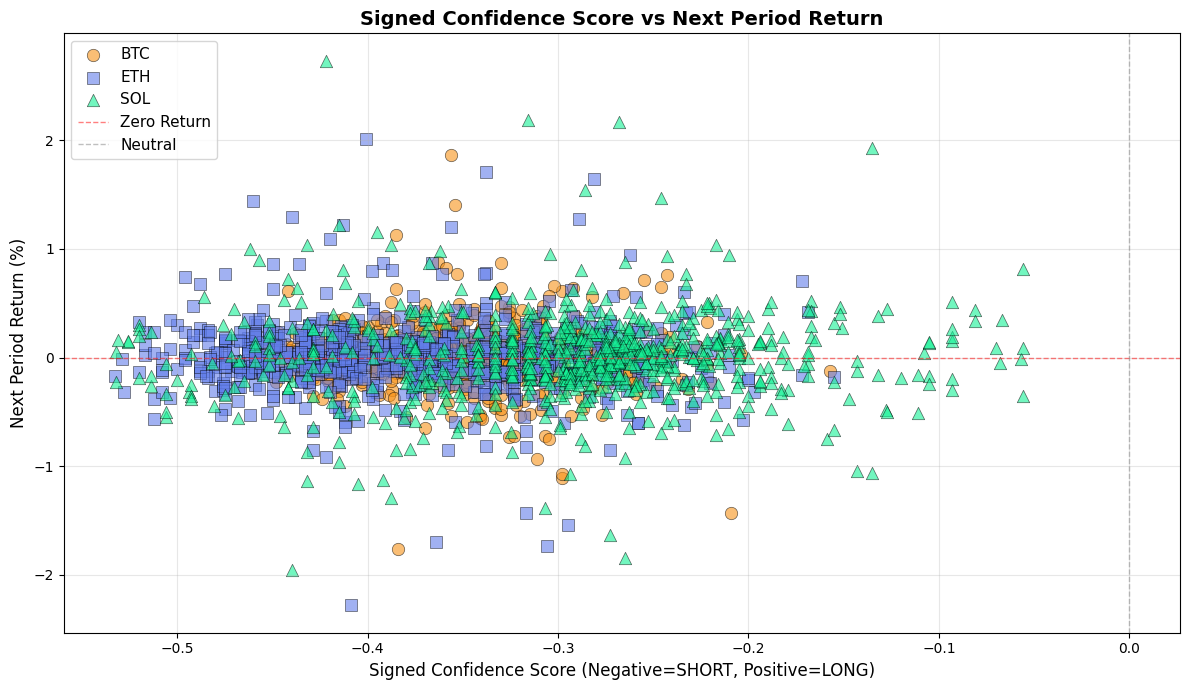

CORRELATION: SIGNED CONFIDENCE SCORE vs RETURN
BTC: -0.0508
ETH: -0.0323
SOL: 0.0405


In [7]:
import matplotlib.pyplot as plt

# Create signed confidence score (negative for SHORT, positive for LONG)
df_results['signed_confidence'] = df_results['confidence_score'] * df_results['position_direction']

# Create scatter plot
plt.figure(figsize=(12, 7))

coins = ['BTC', 'ETH', 'SOL']
colors = ['#F7931A', '#627EEA', '#14F195']  # BTC orange, ETH purple, SOL green
markers = ['o', 's', '^']  # circle, square, triangle

for coin, color, marker in zip(coins, colors, markers):
    coin_data = df_results[df_results['coin'] == coin]
    plt.scatter(coin_data['signed_confidence'], 
                coin_data['price_return'] * 100,  # Convert to percentage
                c=color, 
                label=coin, 
                alpha=0.6, 
                s=80,
                marker=marker,
                edgecolors='black',
                linewidth=0.5)

# Add reference lines
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Zero Return')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Neutral')

plt.title('Signed Confidence Score vs Next Period Return', fontsize=14, fontweight='bold')
plt.xlabel('Signed Confidence Score (Negative=SHORT, Positive=LONG)', fontsize=12)
plt.ylabel('Next Period Return (%)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print correlation statistics
print("="*80)
print("CORRELATION: SIGNED CONFIDENCE SCORE vs RETURN")
print("="*80)
for coin in coins:
    coin_data = df_results[df_results['coin'] == coin]
    correlation = coin_data['signed_confidence'].corr(coin_data['price_return'])
    print(f"{coin}: {correlation:.4f}")

STATISTICAL ANALYSIS: SIGNED CONFIDENCE SCORE vs RETURN

OVERALL (ALL ASSETS COMBINED)
Linear Regression:
  Slope (β): 0.000154
  Intercept: 0.000131
  R² Score: 0.0000

Pearson Correlation: 0.0036 (p-value: 8.6215e-01)
Spearman Correlation: 0.0022 (p-value: 9.1530e-01)
✗ No statistically significant correlation (p >= 0.05)

BY ASSET

BTC:
  Sample size: 760
  Slope (β): -0.002862
  R² Score: 0.0026
  Pearson: -0.0508 (p=1.6184e-01)
  Spearman: -0.0504 (p=1.6509e-01)
  Significant: ✗ No

ETH:
  Sample size: 760
  Slope (β): -0.001436
  R² Score: 0.0010
  Pearson: -0.0323 (p=3.7410e-01)
  Spearman: -0.0297 (p=4.1341e-01)
  Significant: ✗ No

SOL:
  Sample size: 760
  Slope (β): 0.001842
  R² Score: 0.0016
  Pearson: 0.0405 (p=2.6424e-01)
  Spearman: 0.0498 (p=1.7040e-01)
  Significant: ✗ No

SUMMARY TABLE


,Coin,N,Slope,R²,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,BTC,760,-0.002862,0.002580,-0.050794,0.161842,-0.050404,0.165093
1,ETH,760,-0.001436,0.001042,-0.032285,0.374102,-0.029711,0.413406
2,SOL,760,0.001842,0.001644,0.040547,0.264236,0.049779,0.170401


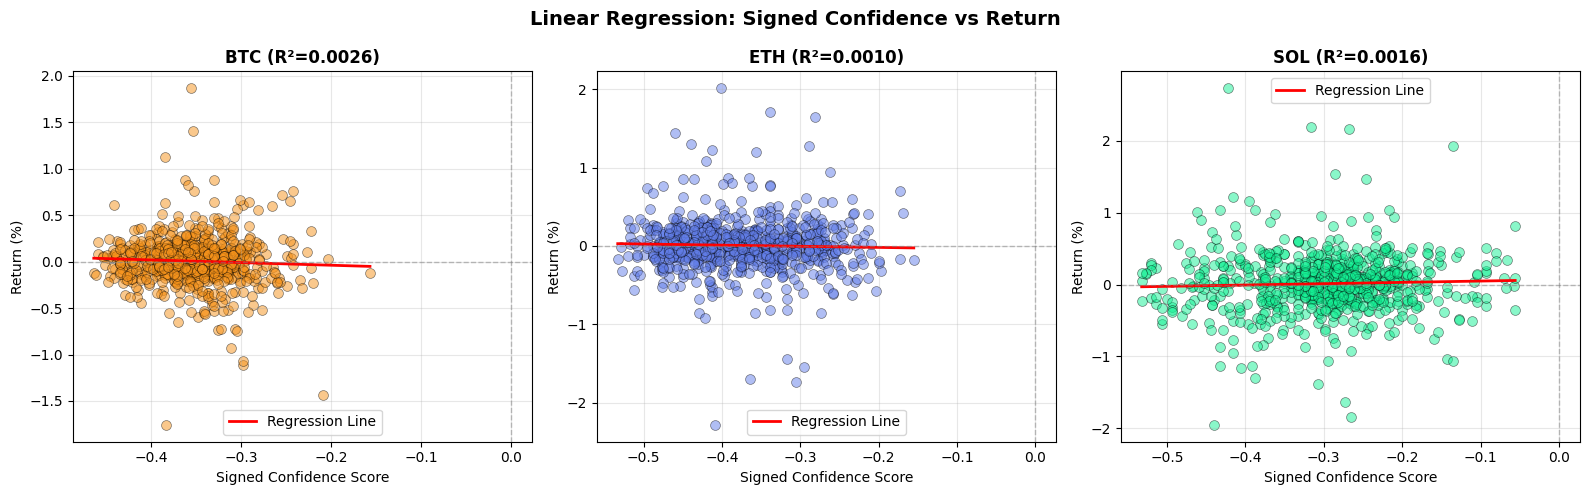

In [8]:
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

print("="*80)
print("STATISTICAL ANALYSIS: SIGNED CONFIDENCE SCORE vs RETURN")
print("="*80)

# Overall analysis
print("\n" + "="*80)
print("OVERALL (ALL ASSETS COMBINED)")
print("="*80)

X = df_results['signed_confidence'].values.reshape(-1, 1)
y = df_results['price_return'].values

# Linear Regression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)

# Pearson Correlation
pearson_corr, pearson_pval = stats.pearsonr(df_results['signed_confidence'], df_results['price_return'])

# Spearman Correlation (non-parametric)
spearman_corr, spearman_pval = stats.spearmanr(df_results['signed_confidence'], df_results['price_return'])

print(f"Linear Regression:")
print(f"  Slope (β): {lr.coef_[0]:.6f}")
print(f"  Intercept: {lr.intercept_:.6f}")
print(f"  R² Score: {r2:.4f}")
print(f"\nPearson Correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4e})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4e})")

if pearson_pval < 0.05:
    print(f"✓ Statistically significant correlation (p < 0.05)")
else:
    print(f"✗ No statistically significant correlation (p >= 0.05)")

# Analysis by coin
print("\n" + "="*80)
print("BY ASSET")
print("="*80)

results_by_coin = []

for coin in ['BTC', 'ETH', 'SOL']:
    coin_data = df_results[df_results['coin'] == coin]
    
    X_coin = coin_data['signed_confidence'].values.reshape(-1, 1)
    y_coin = coin_data['price_return'].values
    
    # Linear Regression
    lr_coin = LinearRegression()
    lr_coin.fit(X_coin, y_coin)
    y_pred_coin = lr_coin.predict(X_coin)
    r2_coin = r2_score(y_coin, y_pred_coin)
    
    # Correlations
    pearson_corr_coin, pearson_pval_coin = stats.pearsonr(coin_data['signed_confidence'], coin_data['price_return'])
    spearman_corr_coin, spearman_pval_coin = stats.spearmanr(coin_data['signed_confidence'], coin_data['price_return'])
    
    print(f"\n{coin}:")
    print(f"  Sample size: {len(coin_data)}")
    print(f"  Slope (β): {lr_coin.coef_[0]:.6f}")
    print(f"  R² Score: {r2_coin:.4f}")
    print(f"  Pearson: {pearson_corr_coin:.4f} (p={pearson_pval_coin:.4e})")
    print(f"  Spearman: {spearman_corr_coin:.4f} (p={spearman_pval_coin:.4e})")
    print(f"  Significant: {'✓ Yes' if pearson_pval_coin < 0.05 else '✗ No'}")
    
    results_by_coin.append({
        'Coin': coin,
        'N': len(coin_data),
        'Slope': lr_coin.coef_[0],
        'R²': r2_coin,
        'Pearson_r': pearson_corr_coin,
        'Pearson_p': pearson_pval_coin,
        'Spearman_r': spearman_corr_coin,
        'Spearman_p': spearman_pval_coin
    })

# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
summary_df = pd.DataFrame(results_by_coin)
display(summary_df.round(6))

# Visualize regression lines
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Linear Regression: Signed Confidence vs Return', fontsize=14, fontweight='bold')

coins = ['BTC', 'ETH', 'SOL']
colors = ['#F7931A', '#627EEA', '#14F195']

for idx, (coin, color) in enumerate(zip(coins, colors)):
    coin_data = df_results[df_results['coin'] == coin]
    
    X_coin = coin_data['signed_confidence'].values.reshape(-1, 1)
    y_coin = coin_data['price_return'].values * 100  # percentage
    
    lr_coin = LinearRegression()
    lr_coin.fit(X_coin, y_coin)
    
    # Plot
    ax = axes[idx]
    ax.scatter(coin_data['signed_confidence'], y_coin, 
               c=color, alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
    
    # Regression line
    X_line = np.linspace(coin_data['signed_confidence'].min(), 
                         coin_data['signed_confidence'].max(), 100).reshape(-1, 1)
    y_line = lr_coin.predict(X_line)
    ax.plot(X_line, y_line, color='red', linewidth=2, label=f'Regression Line')
    
    # Reference lines
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    r2_coin = r2_score(y_coin, lr_coin.predict(X_coin))
    ax.set_title(f'{coin} (R²={r2_coin:.4f})', fontweight='bold')
    ax.set_xlabel('Signed Confidence Score')
    ax.set_ylabel('Return (%)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Filtering Divergence Signals

It is not what I meant but actually I dont really know what i wanted. The idea was to take shorts when the cofidence score is rising and the price is rising as well, and the opposite for longs. Perhaps i just wanted to know if when there is a divergence, what is the price reaction.

In [9]:
# Calculate change in confidence score from previous period
df_results['prev_signed_confidence'] = df_results.groupby('coin')['signed_confidence'].shift(1)
df_results['confidence_change'] = df_results['signed_confidence'] - df_results['prev_signed_confidence']

# Identify divergences
# Divergence = confidence decreases while price increases (or vice versa)
# For simplicity: divergence when confidence_change and price_return have opposite signs
df_results['is_divergence'] = (
    ((df_results['confidence_change'] < 0) & (df_results['price_return'] > 0)) |
    ((df_results['confidence_change'] > 0) & (df_results['price_return'] < 0))
)

# Remove first row of each coin (no previous confidence)
df_results_div = df_results.dropna(subset=['confidence_change']).reset_index(drop=True)

print("="*80)
print("DIVERGENCE ANALYSIS OVERVIEW")
print("="*80)
print(f"\nTotal periods analyzed: {len(df_results_div)}")
print(f"Divergence periods: {df_results_div['is_divergence'].sum()}")
print(f"Divergence rate: {df_results_div['is_divergence'].sum() / len(df_results_div) * 100:.2f}%")

print("\n" + "="*80)
print("DIVERGENCES BY COIN")
print("="*80)
divergence_by_coin = df_results_div.groupby('coin').agg({
    'is_divergence': ['sum', 'mean']
}).round(4)
divergence_by_coin.columns = ['Divergence_Count', 'Divergence_Rate']
display(divergence_by_coin)

# Show sample divergences
print("\n" + "="*80)
print("SAMPLE DIVERGENCE PERIODS")
print("="*80)
display(df_results_div[df_results_div['is_divergence']][
    ['coin', 'timestamp', 'signed_confidence', 'prev_signed_confidence', 
     'confidence_change', 'price_return', 'is_divergence']
].head(10))

DIVERGENCE ANALYSIS OVERVIEW

Total periods analyzed: 2277
Divergence periods: 962
Divergence rate: 42.25%

DIVERGENCES BY COIN


,Divergence_Count,Divergence_Rate
coin,,
BTC,347,0.4572
ETH,311,0.4097
SOL,304,0.4005



SAMPLE DIVERGENCE PERIODS


,coin,timestamp,signed_confidence,prev_signed_confidence,confidence_change,price_return,is_divergence
1,BTC,2025-12-23 10:10:08,-0.273,-0.254,-0.019,0.000789,True
2,BTC,2025-12-23 10:40:42,-0.285,-0.273,-0.012,0.000982,True
3,BTC,2025-12-23 11:11:17,-0.317,-0.285,-0.032,0.000970,True
5,BTC,2025-12-23 12:12:25,-0.320,-0.314,-0.006,0.000046,True
7,BTC,2025-12-23 13:13:34,-0.307,-0.321,0.014,-0.001003,True
9,BTC,2025-12-23 14:14:43,-0.287,-0.290,0.003,-0.004695,True
10,BTC,2025-12-23 14:45:21,-0.277,-0.287,0.010,-0.002862,True
11,BTC,2025-12-23 15:15:56,-0.320,-0.277,-0.043,0.002457,True
12,BTC,2025-12-23 15:46:30,-0.350,-0.320,-0.030,0.000389,True
13,BTC,2025-12-23 15:48:56,-0.353,-0.350,-0.003,0.007643,True


In [10]:
# Test strategy: What if we fade divergences?
# When divergence occurs, take the OPPOSITE position of what confidence suggests

# Calculate position for divergence strategy
# If divergence: reverse the signal (multiply by -1)
# If no divergence: follow the signal normally
df_results_div['div_position_direction'] = np.where(
    df_results_div['is_divergence'],
    -df_results_div['position_direction'],  # Reverse
    df_results_div['position_direction']     # Keep same
)

# Calculate P&L for divergence strategy
df_results_div['div_period_pnl'] = (
    df_results_div['position_size'] * 
    df_results_div['div_position_direction'] * 
    df_results_div['price_return']
)

# Calculate cumulative P&L for both strategies
df_results_div['original_cumulative_pnl'] = df_results_div.groupby('coin')['period_pnl'].cumsum()
df_results_div['div_cumulative_pnl'] = df_results_div.groupby('coin')['div_period_pnl'].cumsum()

print("="*80)
print("STRATEGY COMPARISON: ORIGINAL vs DIVERGENCE-AWARE")
print("="*80)

# Overall performance comparison
print("\nOVERALL PERFORMANCE:")
print("-" * 40)
print(f"Original Strategy:")
print(f"  Total P&L: ${df_results_div['period_pnl'].sum():.2f}")
print(f"  Average P&L: ${df_results_div['period_pnl'].mean():.2f}")
print(f"  Win Rate: {(df_results_div['period_pnl'] > 0).sum() / len(df_results_div) * 100:.2f}%")

print(f"\nDivergence Strategy (fade divergences):")
print(f"  Total P&L: ${df_results_div['div_period_pnl'].sum():.2f}")
print(f"  Average P&L: ${df_results_div['div_period_pnl'].mean():.2f}")
print(f"  Win Rate: {(df_results_div['div_period_pnl'] > 0).sum() / len(df_results_div) * 100:.2f}%")

improvement = df_results_div['div_period_pnl'].sum() - df_results_div['period_pnl'].sum()
print(f"\nImprovement: ${improvement:.2f} ({improvement / abs(df_results_div['period_pnl'].sum()) * 100:.2f}%)")

# Performance by coin
print("\n" + "="*80)
print("PERFORMANCE BY COIN")
print("="*80)

comparison_by_coin = df_results_div.groupby('coin').agg({
    'period_pnl': ['sum', 'mean'],
    'div_period_pnl': ['sum', 'mean']
}).round(2)
comparison_by_coin.columns = ['Original_Total', 'Original_Avg', 'Divergence_Total', 'Divergence_Avg']
display(comparison_by_coin)

STRATEGY COMPARISON: ORIGINAL vs DIVERGENCE-AWARE

OVERALL PERFORMANCE:
----------------------------------------
Original Strategy:
  Total P&L: $-2022.14
  Average P&L: $-0.89
  Win Rate: 47.96%

Divergence Strategy (fade divergences):
  Total P&L: $467.19
  Average P&L: $0.21
  Win Rate: 49.71%

Improvement: $2489.34 (123.10%)

PERFORMANCE BY COIN


,Original_Total,Original_Avg,Divergence_Total,Divergence_Avg
coin,,,,
BTC,-569.19,-0.75,-416.76,-0.55
ETH,-933.73,-1.23,231.14,0.30
SOL,-519.22,-0.68,652.81,0.86


In [11]:
# Analyze performance specifically during divergence vs non-divergence periods

print("="*80)
print("PERFORMANCE: DIVERGENCE vs NON-DIVERGENCE PERIODS")
print("="*80)

# Separate divergence and non-divergence periods
div_periods = df_results_div[df_results_div['is_divergence']]
non_div_periods = df_results_div[~df_results_div['is_divergence']]

print("\nDIVERGENCE PERIODS:")
print("-" * 40)
print(f"Count: {len(div_periods)}")
print(f"Original Strategy P&L: ${div_periods['period_pnl'].sum():.2f}")
print(f"Average P&L: ${div_periods['period_pnl'].mean():.2f}")
print(f"Divergence Strategy P&L: ${div_periods['div_period_pnl'].sum():.2f}")
print(f"Average P&L: ${div_periods['div_period_pnl'].mean():.2f}")

print("\nNON-DIVERGENCE PERIODS:")
print("-" * 40)
print(f"Count: {len(non_div_periods)}")
print(f"Original Strategy P&L: ${non_div_periods['period_pnl'].sum():.2f}")
print(f"Average P&L: ${non_div_periods['period_pnl'].mean():.2f}")
print(f"Divergence Strategy P&L: ${non_div_periods['div_period_pnl'].sum():.2f}")
print(f"Average P&L: ${non_div_periods['div_period_pnl'].mean():.2f}")

# By coin
print("\n" + "="*80)
print("DIVERGENCE PERIOD PERFORMANCE BY COIN")
print("="*80)

for coin in ['BTC', 'ETH', 'SOL']:
    coin_div = div_periods[div_periods['coin'] == coin]
    print(f"\n{coin}:")
    print(f"  Divergence periods: {len(coin_div)}")
    print(f"  Original P&L: ${coin_div['period_pnl'].sum():.2f}")
    print(f"  Divergence Strategy P&L: ${coin_div['div_period_pnl'].sum():.2f}")

PERFORMANCE: DIVERGENCE vs NON-DIVERGENCE PERIODS

DIVERGENCE PERIODS:
----------------------------------------
Count: 962
Original Strategy P&L: $-1244.67
Average P&L: $-1.29
Divergence Strategy P&L: $1244.67
Average P&L: $1.29

NON-DIVERGENCE PERIODS:
----------------------------------------
Count: 1315
Original Strategy P&L: $-777.47
Average P&L: $-0.59
Divergence Strategy P&L: $-777.47
Average P&L: $-0.59

DIVERGENCE PERIOD PERFORMANCE BY COIN

BTC:
  Divergence periods: 347
  Original P&L: $-76.22
  Divergence Strategy P&L: $76.22

ETH:
  Divergence periods: 311
  Original P&L: $-582.44
  Divergence Strategy P&L: $582.44

SOL:
  Divergence periods: 304
  Original P&L: $-586.01
  Divergence Strategy P&L: $586.01


In [12]:
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("="*80)
print("STATISTICAL ANALYSIS: CONFIDENCE CHANGE vs RETURN")
print("="*80)

# Overall analysis
print("\n" + "="*80)
print("OVERALL (ALL ASSETS COMBINED)")
print("="*80)

X = df_results_div['confidence_change'].values.reshape(-1, 1)
y = df_results_div['price_return'].values

# Linear Regression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)

# Pearson Correlation
pearson_corr, pearson_pval = stats.pearsonr(df_results_div['confidence_change'], df_results_div['price_return'])

# Spearman Correlation
spearman_corr, spearman_pval = stats.spearmanr(df_results_div['confidence_change'], df_results_div['price_return'])

print(f"Linear Regression:")
print(f"  Slope (β): {lr.coef_[0]:.6f}")
print(f"  Intercept: {lr.intercept_:.6f}")
print(f"  R² Score: {r2:.4f}")
print(f"\nPearson Correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4e})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4e})")

if pearson_pval < 0.05:
    print(f"✓ Statistically significant correlation (p < 0.05)")
else:
    print(f"✗ No statistically significant correlation (p >= 0.05)")

# Analysis by coin
print("\n" + "="*80)
print("BY ASSET")
print("="*80)

results_by_coin = []

for coin in ['BTC', 'ETH', 'SOL']:
    coin_data = df_results_div[df_results_div['coin'] == coin]
    
    X_coin = coin_data['confidence_change'].values.reshape(-1, 1)
    y_coin = coin_data['price_return'].values
    
    # Linear Regression
    lr_coin = LinearRegression()
    lr_coin.fit(X_coin, y_coin)
    y_pred_coin = lr_coin.predict(X_coin)
    r2_coin = r2_score(y_coin, y_pred_coin)
    
    # Correlations
    pearson_corr_coin, pearson_pval_coin = stats.pearsonr(coin_data['confidence_change'], coin_data['price_return'])
    spearman_corr_coin, spearman_pval_coin = stats.spearmanr(coin_data['confidence_change'], coin_data['price_return'])
    
    print(f"\n{coin}:")
    print(f"  Sample size: {len(coin_data)}")
    print(f"  Slope (β): {lr_coin.coef_[0]:.6f}")
    print(f"  R² Score: {r2_coin:.4f}")
    print(f"  Pearson: {pearson_corr_coin:.4f} (p={pearson_pval_coin:.4e})")
    print(f"  Spearman: {spearman_corr_coin:.4f} (p={spearman_pval_coin:.4e})")
    print(f"  Significant: {'✓ Yes' if pearson_pval_coin < 0.05 else '✗ No'}")
    
    results_by_coin.append({
        'Coin': coin,
        'N': len(coin_data),
        'Slope': lr_coin.coef_[0],
        'R²': r2_coin,
        'Pearson_r': pearson_corr_coin,
        'Pearson_p': pearson_pval_coin,
        'Spearman_r': spearman_corr_coin,
        'Spearman_p': spearman_pval_coin
    })

# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
summary_df = pd.DataFrame(results_by_coin)
display(summary_df.round(6))

STATISTICAL ANALYSIS: CONFIDENCE CHANGE vs RETURN

OVERALL (ALL ASSETS COMBINED)
Linear Regression:
  Slope (β): -0.004786
  Intercept: 0.000081
  R² Score: 0.0007

Pearson Correlation: -0.0267 (p-value: 2.0228e-01)
Spearman Correlation: -0.0415 (p-value: 4.7800e-02)
✗ No statistically significant correlation (p >= 0.05)

BY ASSET

BTC:
  Sample size: 759
  Slope (β): -0.001536
  R² Score: 0.0001
  Pearson: -0.0104 (p=7.7480e-01)
  Spearman: -0.0210 (p=5.6288e-01)
  Significant: ✗ No

ETH:
  Sample size: 759
  Slope (β): 0.002389
  R² Score: 0.0001
  Pearson: 0.0116 (p=7.5009e-01)
  Spearman: -0.0169 (p=6.4114e-01)
  Significant: ✗ No

SOL:
  Sample size: 759
  Slope (β): -0.010463
  R² Score: 0.0033
  Pearson: -0.0578 (p=1.1133e-01)
  Spearman: -0.0721 (p=4.7014e-02)
  Significant: ✗ No

SUMMARY TABLE


,Coin,N,Slope,R²,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,BTC,759,-0.001536,0.000108,-0.010402,0.774798,-0.021033,0.562881
1,ETH,759,0.002389,0.000134,0.011580,0.750087,-0.016945,0.641138
2,SOL,759,-0.010463,0.003346,-0.057841,0.111333,-0.072119,0.047014


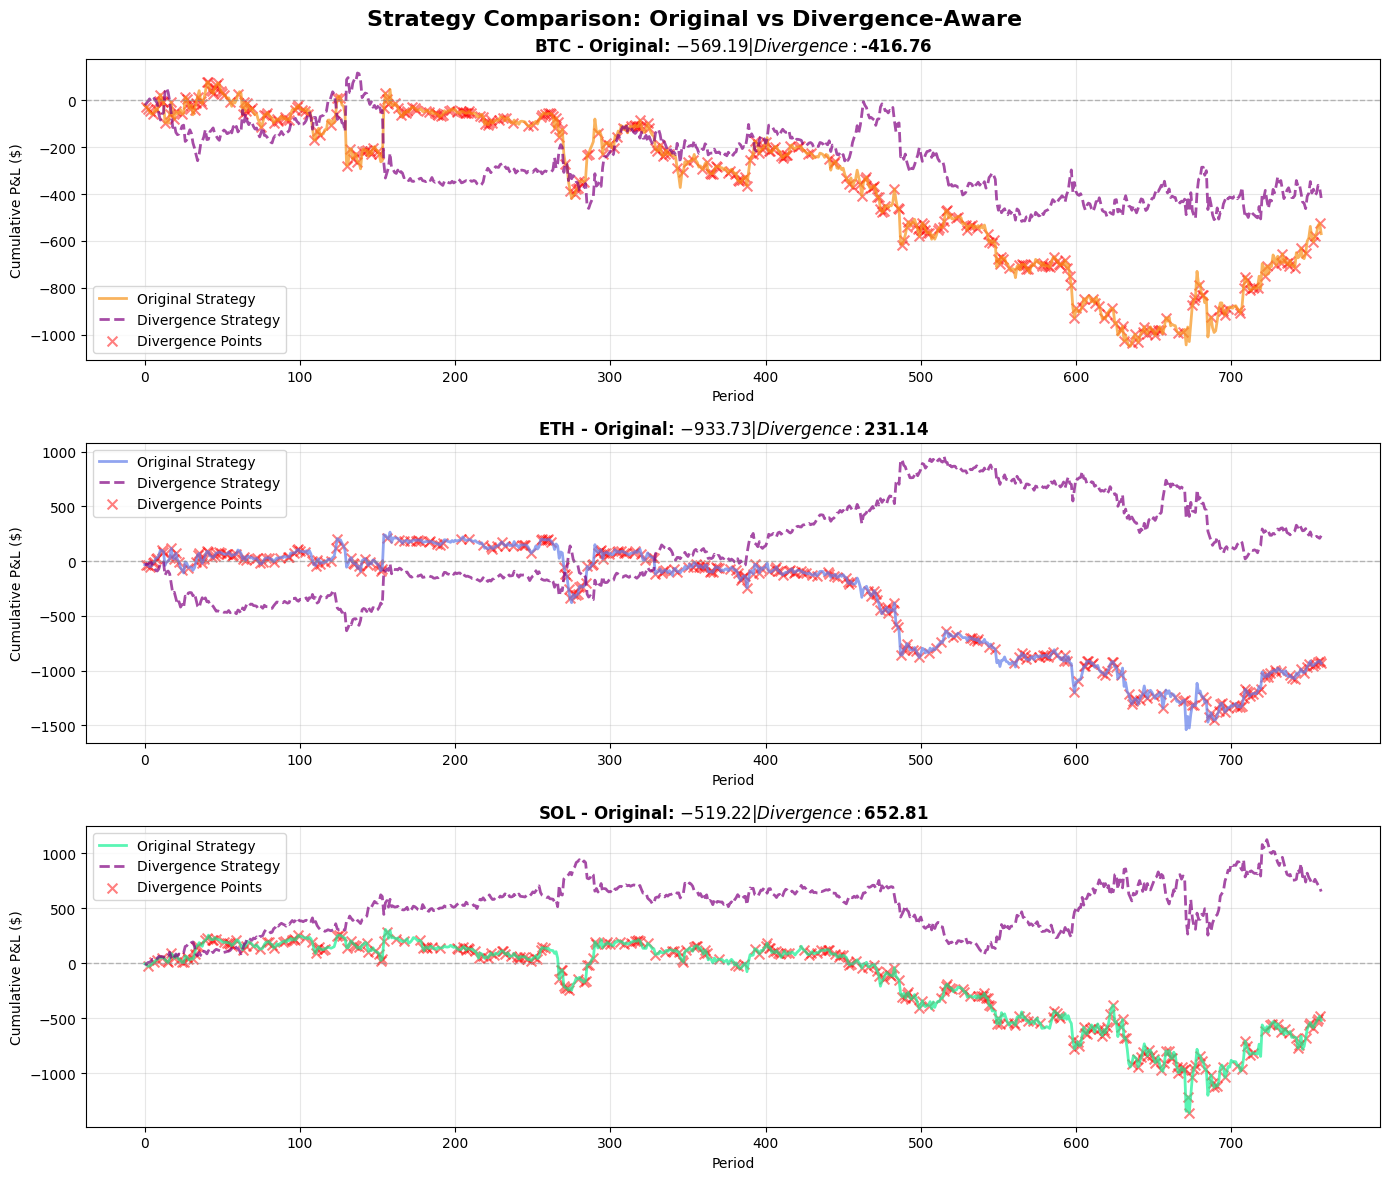

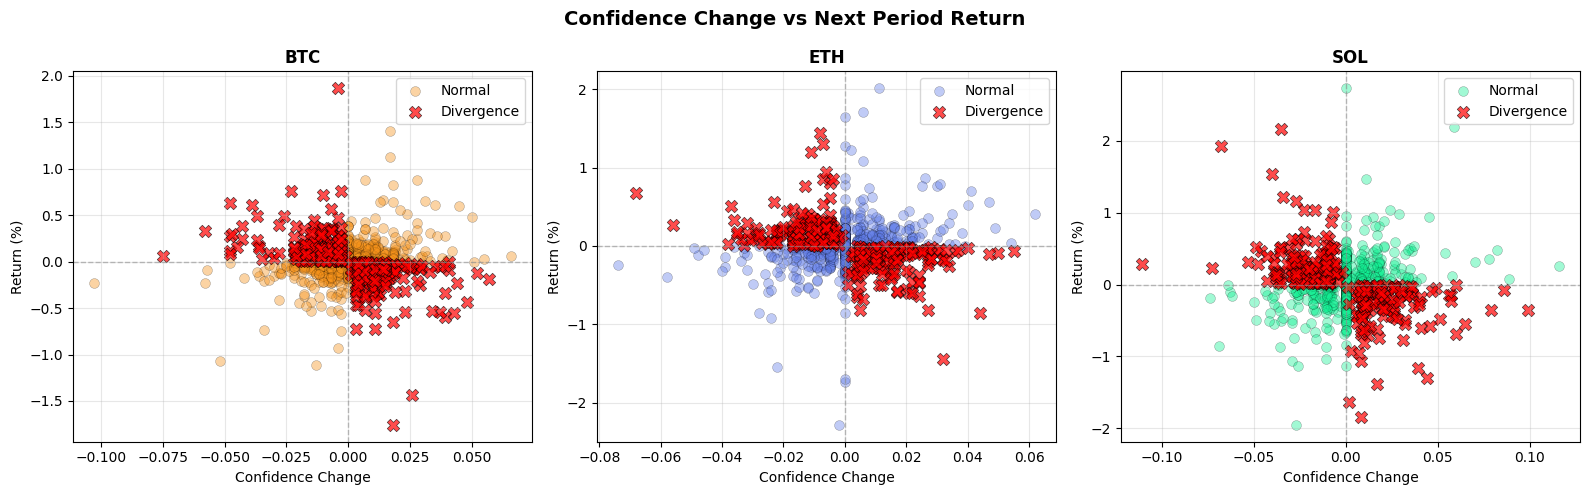

In [13]:
import matplotlib.pyplot as plt

# Plot cumulative P&L comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Strategy Comparison: Original vs Divergence-Aware', fontsize=16, fontweight='bold')

coins = ['BTC', 'ETH', 'SOL']
colors = ['#F7931A', '#627EEA', '#14F195']

for idx, (coin, color) in enumerate(zip(coins, colors)):
    coin_data = df_results_div[df_results_div['coin'] == coin].copy()
    
    ax = axes[idx]
    
    # Plot both strategies
    ax.plot(range(len(coin_data)), coin_data['original_cumulative_pnl'], 
            color=color, linewidth=2, label='Original Strategy', alpha=0.7)
    ax.plot(range(len(coin_data)), coin_data['div_cumulative_pnl'], 
            color='purple', linewidth=2, label='Divergence Strategy', linestyle='--', alpha=0.7)
    
    # Mark divergence points
    div_points = coin_data[coin_data['is_divergence']]
    ax.scatter(div_points.index - coin_data.index[0], 
               div_points['original_cumulative_pnl'],
               color='red', s=50, alpha=0.5, marker='x', label='Divergence Points')
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    original_final = coin_data['original_cumulative_pnl'].iloc[-1]
    div_final = coin_data['div_cumulative_pnl'].iloc[-1]
    
    ax.set_title(f'{coin} - Original: ${original_final:.2f} | Divergence: ${div_final:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Period')
    ax.set_ylabel('Cumulative P&L ($)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

# Scatter plot: Confidence Change vs Return
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confidence Change vs Next Period Return', fontsize=14, fontweight='bold')

for idx, (coin, color) in enumerate(zip(coins, colors)):
    coin_data = df_results_div[df_results_div['coin'] == coin]
    
    ax = axes[idx]
    
    # Non-divergence points
    non_div = coin_data[~coin_data['is_divergence']]
    ax.scatter(non_div['confidence_change'], non_div['price_return'] * 100,
               c=color, alpha=0.4, s=50, label='Normal', edgecolors='black', linewidth=0.3)
    
    # Divergence points
    div = coin_data[coin_data['is_divergence']]
    ax.scatter(div['confidence_change'], div['price_return'] * 100,
               c='red', alpha=0.7, s=80, marker='X', label='Divergence', edgecolors='black', linewidth=0.5)
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_title(f'{coin}', fontweight='bold')
    ax.set_xlabel('Confidence Change')
    ax.set_ylabel('Return (%)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Divergence Next Period

In [14]:
# Calculate confidence change (unsigned, just looking at the score magnitude)
df_results['prev_confidence_score'] = df_results.groupby('coin')['confidence_score'].shift(1)
df_results['confidence_score_change'] = df_results['confidence_score'] - df_results['prev_confidence_score']

# Identify divergences:
# 1. SHORT signal + confidence rising + price rising
# 2. LONG signal + confidence rising + price falling
df_results['is_divergence'] = (
    ((df_results['signal_direction'] == 'SHORT') & 
     (df_results['confidence_score_change'] > 0) & 
     (df_results['price_return'] > 0)) |
    ((df_results['signal_direction'] == 'LONG') & 
     (df_results['confidence_score_change'] > 0) & 
     (df_results['price_return'] < 0))
)

# Get next period return for divergences
df_results['next_period_return'] = df_results.groupby('coin')['price_return'].shift(-1)

# Remove rows without complete data
df_divergence = df_results.dropna(subset=['confidence_score_change', 'next_period_return']).copy()

print("="*80)
print("DIVERGENCE ANALYSIS")
print("="*80)
print(f"\nTotal periods: {len(df_divergence)}")
print(f"Divergences found: {df_divergence['is_divergence'].sum()}")
print(f"Divergence rate: {df_divergence['is_divergence'].sum() / len(df_divergence) * 100:.2f}%")

# Show sample divergences
print("\n" + "="*80)
print("SAMPLE DIVERGENCES")
print("="*80)
display(df_divergence[df_divergence['is_divergence']][
    ['coin', 'timestamp', 'signal_direction', 'confidence_score', 'confidence_score_change', 
     'price_return', 'next_period_return']
].head(10))

DIVERGENCE ANALYSIS

Total periods: 2274
Divergences found: 500
Divergence rate: 21.99%

SAMPLE DIVERGENCES


,coin,timestamp,signal_direction,confidence_score,confidence_score_change,price_return,next_period_return
2,BTC,2025-12-23 10:10:08,SHORT,0.273,0.019,0.000789,0.000982
3,BTC,2025-12-23 10:40:42,SHORT,0.285,0.012,0.000982,0.000970
4,BTC,2025-12-23 11:11:17,SHORT,0.317,0.032,0.000970,0.001071
6,BTC,2025-12-23 12:12:25,SHORT,0.320,0.006,0.000046,-0.001173
12,BTC,2025-12-23 15:15:56,SHORT,0.320,0.043,0.002457,0.000389
13,BTC,2025-12-23 15:46:30,SHORT,0.350,0.030,0.000389,0.007643
14,BTC,2025-12-23 15:48:56,SHORT,0.353,0.003,0.007643,-0.001347
20,BTC,2025-12-23 18:32:18,SHORT,0.346,0.048,0.001104,-0.003138
25,BTC,2025-12-23 21:05:10,SHORT,0.378,0.045,0.001552,-0.000251
28,BTC,2025-12-23 22:36:52,SHORT,0.393,0.013,0.000510,0.001787


In [15]:
# Separate divergence and non-divergence periods
divergence_periods = df_divergence[df_divergence['is_divergence']]
normal_periods = df_divergence[~df_divergence['is_divergence']]

print("="*80)
print("NEXT PERIOD RETURN STATISTICS")
print("="*80)

print("\nAFTER DIVERGENCE:")
print("-" * 40)
print(f"Count: {len(divergence_periods)}")
print(f"Mean return: {divergence_periods['next_period_return'].mean() * 100:.4f}%")
print(f"Median return: {divergence_periods['next_period_return'].median() * 100:.4f}%")
print(f"Std deviation: {divergence_periods['next_period_return'].std() * 100:.4f}%")
print(f"Min return: {divergence_periods['next_period_return'].min() * 100:.4f}%")
print(f"Max return: {divergence_periods['next_period_return'].max() * 100:.4f}%")
print(f"Positive returns: {(divergence_periods['next_period_return'] > 0).sum()} ({(divergence_periods['next_period_return'] > 0).sum() / len(divergence_periods) * 100:.2f}%)")

print("\nAFTER NORMAL PERIODS (for comparison):")
print("-" * 40)
print(f"Count: {len(normal_periods)}")
print(f"Mean return: {normal_periods['next_period_return'].mean() * 100:.4f}%")
print(f"Median return: {normal_periods['next_period_return'].median() * 100:.4f}%")
print(f"Std deviation: {normal_periods['next_period_return'].std() * 100:.4f}%")
print(f"Min return: {normal_periods['next_period_return'].min() * 100:.4f}%")
print(f"Max return: {normal_periods['next_period_return'].max() * 100:.4f}%")
print(f"Positive returns: {(normal_periods['next_period_return'] > 0).sum()} ({(normal_periods['next_period_return'] > 0).sum() / len(normal_periods) * 100:.2f}%)")

# By coin
print("\n" + "="*80)
print("BY COIN")
print("="*80)

for coin in ['BTC', 'ETH', 'SOL']:
    coin_div = divergence_periods[divergence_periods['coin'] == coin]
    coin_normal = normal_periods[normal_periods['coin'] == coin]
    
    print(f"\n{coin}:")
    print(f"  Divergences: {len(coin_div)}")
    if len(coin_div) > 0:
        print(f"    Mean next return: {coin_div['next_period_return'].mean() * 100:.4f}%")
        print(f"    Positive rate: {(coin_div['next_period_return'] > 0).sum() / len(coin_div) * 100:.2f}%")
    print(f"  Normal periods: {len(coin_normal)}")
    if len(coin_normal) > 0:
        print(f"    Mean next return: {coin_normal['next_period_return'].mean() * 100:.4f}%")
        print(f"    Positive rate: {(coin_normal['next_period_return'] > 0).sum() / len(coin_normal) * 100:.2f}%")

NEXT PERIOD RETURN STATISTICS

AFTER DIVERGENCE:
----------------------------------------
Count: 500
Mean return: 0.0025%
Median return: -0.0079%
Std deviation: 0.3077%
Min return: -1.5406%
Max return: 1.4714%
Positive returns: 242 (48.40%)

AFTER NORMAL PERIODS (for comparison):
----------------------------------------
Count: 1774
Mean return: 0.0093%
Median return: 0.0151%
Std deviation: 0.3433%
Min return: -2.2813%
Max return: 2.7325%
Positive returns: 929 (52.37%)

BY COIN

BTC:
  Divergences: 180
    Mean next return: -0.0013%
    Positive rate: 50.00%
  Normal periods: 578
    Mean next return: 0.0063%
    Positive rate: 51.73%

ETH:
  Divergences: 156
    Mean next return: -0.0124%
    Positive rate: 42.31%
  Normal periods: 602
    Mean next return: 0.0124%
    Positive rate: 53.32%

SOL:
  Divergences: 164
    Mean next return: 0.0210%
    Positive rate: 52.44%
  Normal periods: 594
    Mean next return: 0.0092%
    Positive rate: 52.02%
